In [6]:
import numpy as np

image = np.array([
    [0, 0, 0, 4],
    [1, 1, 1, 5],
    [1, 2, 2, 7],
    [2, 2, 2, 7]
])

print("The original Photo")
print(image)
print("\n")


total_pixels = image.size # عدد البيكسلز الكلي (16)
L = 8 # عدد مستويات الإضاءة المتاحة (من 0 إلى 7)
max_gray_level = L - 1 # أقصى مستوى إضاءة (7)

freq = {}
pdf = {}
cdf = {}
new_gray_levels = {}


for i in range(L):
    freq[i] = np.sum(image == i)

cumulative_prob = 0
print(f"{'Gray Level':<12} | {'Freq (n)':<10} | {'PDF (p)':<10} | {'CDF':<10} | {'New Value (S)':<10}")
print("-" * 65)

for i in range(L):
    
    pdf[i] = freq[i] / total_pixels
   
    cumulative_prob += pdf[i]
    cdf[i] = cumulative_prob
    new_gray_levels[i] = round(cdf[i] * max_gray_level)
    
    print(f"{i:<12} | {freq[i]:<10} | {pdf[i]:<10.4f} | {cdf[i]:<10.4f} | {new_gray_levels[i]:<10}")


equalized_image = np.zeros_like(image)


for r in range(image.shape[0]):
    for c in range(image.shape[1]):
        old_val = image[r, c]
        equalized_image[r, c] = new_gray_levels[old_val]

print("\n--- The Image after Histogram Equalization ---")
print(equalized_image)

The original Photo
[[0 0 0 4]
 [1 1 1 5]
 [1 2 2 7]
 [2 2 2 7]]


Gray Level   | Freq (n)   | PDF (p)    | CDF        | New Value (S)
-----------------------------------------------------------------
0            | 3          | 0.1875     | 0.1875     | 1         
1            | 4          | 0.2500     | 0.4375     | 3         
2            | 5          | 0.3125     | 0.7500     | 5         
3            | 0          | 0.0000     | 0.7500     | 5         
4            | 1          | 0.0625     | 0.8125     | 6         
5            | 1          | 0.0625     | 0.8750     | 6         
6            | 0          | 0.0000     | 0.8750     | 6         
7            | 2          | 0.1250     | 1.0000     | 7         

--- The Image after Histogram Equalization ---
[[1 1 1 6]
 [3 3 3 6]
 [3 5 5 7]
 [5 5 5 7]]


# Practical application on the histogram

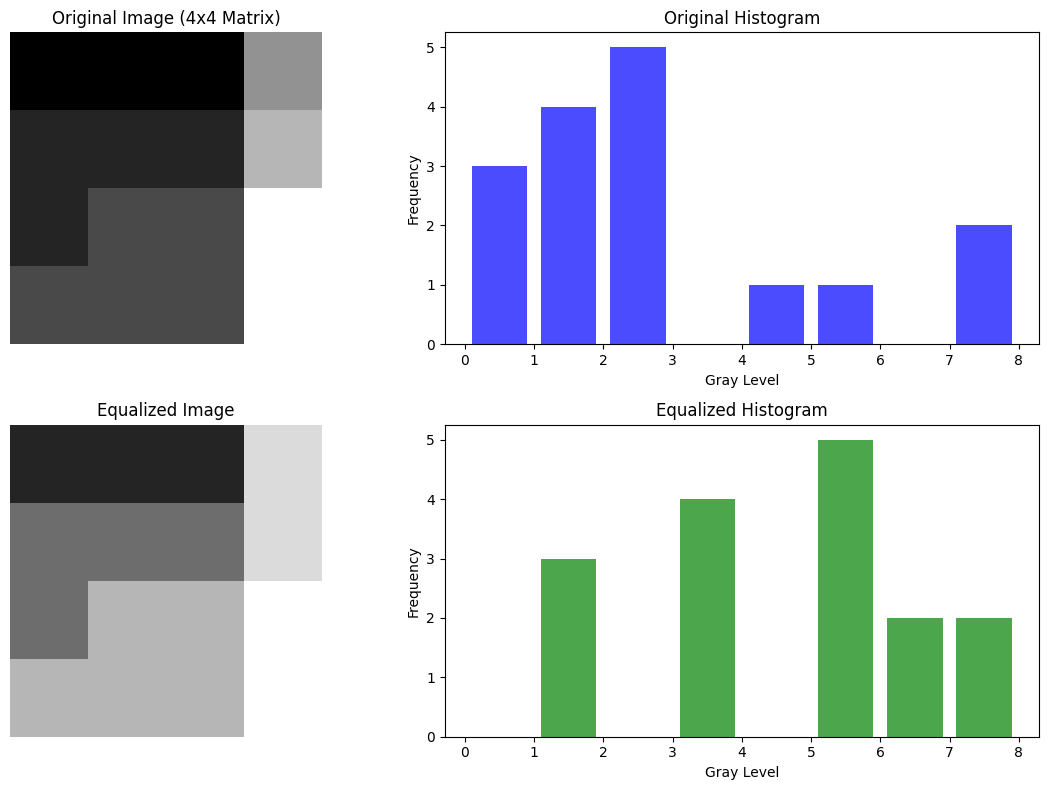

Histogram calculated by OpenCV:
[3. 4. 5. 0. 1. 1. 0. 2.]


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [0, 0, 0, 4],
    [1, 1, 1, 5],
    [1, 2, 2, 7],
    [2, 2, 2, 7]
], dtype=np.uint8)

total_pixels = image.size
L = 8 # مستويات الإضاءة من 0 لـ 7
max_gray_level = L - 1

freq = [np.sum(image == i) for i in range(L)]
pdf = [f / total_pixels for f in freq]

cdf = np.cumsum(pdf) 
s_rounded = np.round(cdf * max_gray_level).astype(np.uint8)


equalized_image = np.zeros_like(image)
for i in range(L):
    equalized_image[image == i] = s_rounded[i]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=7)
plt.title('Original Image (4x4 Matrix)')
plt.axis('off') 

plt.subplot(2, 2, 2)
plt.hist(image.ravel(), bins=L, range=[0, L], color='blue', rwidth=0.8, alpha=0.7)
plt.title('Original Histogram')
plt.xlabel('Gray Level')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.imshow(equalized_image, cmap='gray', vmin=0, vmax=7)
plt.title('Equalized Image')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.hist(equalized_image.ravel(), bins=L, range=[0, L], color='green', rwidth=0.8, alpha=0.7)
plt.title('Equalized Histogram')
plt.xlabel('Gray Level')
plt.ylabel('Frequency')


plt.tight_layout()
plt.show()

hist_cv2 = cv2.calcHist([image], [0], None, [8], [0, 8])
print("Histogram calculated by OpenCV:")
print(hist_cv2.ravel())

# Practical application on the histogram on a real photo

C:\Users\zbook g6\AppData\Local\Temp\ipykernel_14012\4079289000.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(images[i].ravel(), 256, [0, 256], color='black' if i==0 else 'blue')


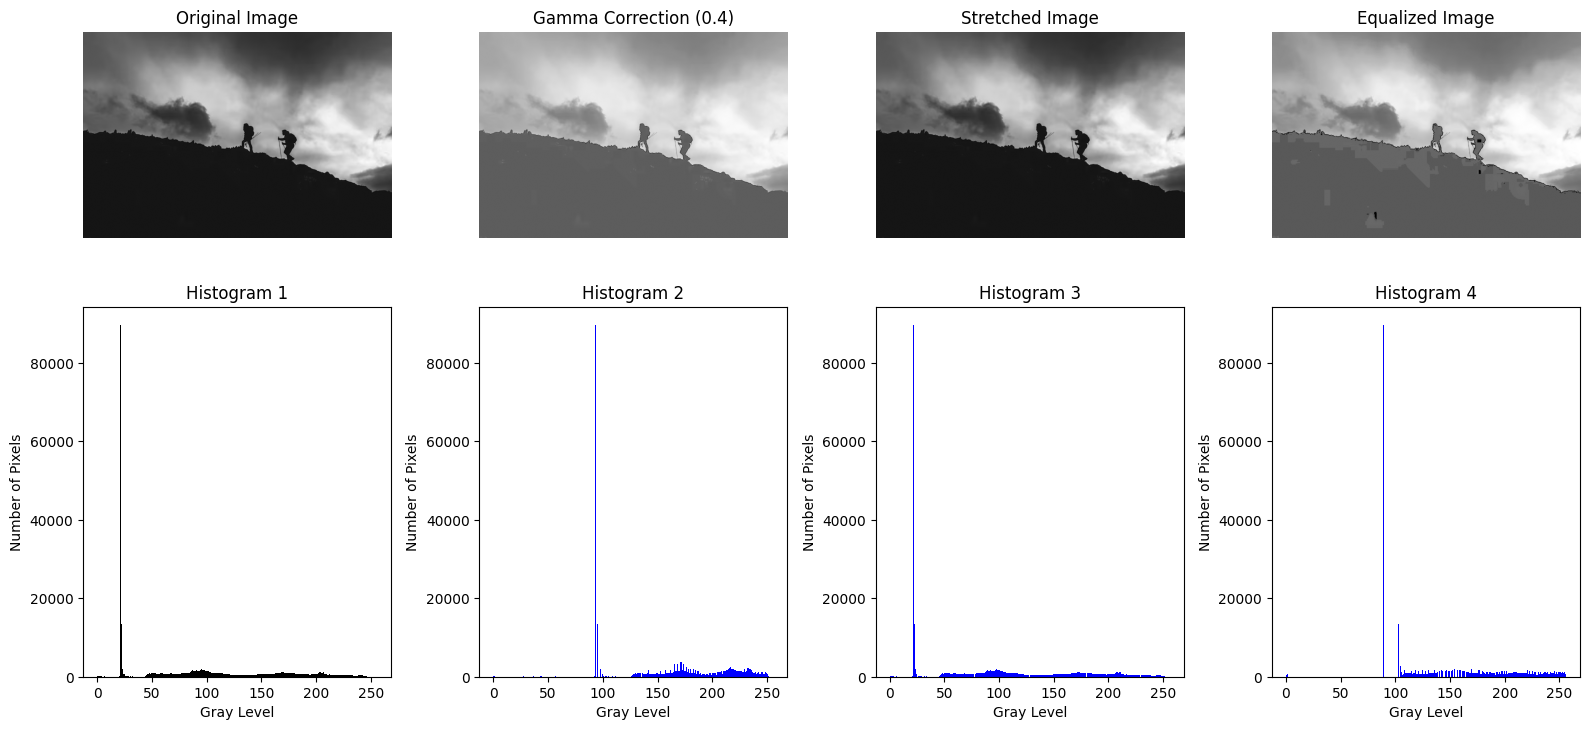

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'hiking.png' 
img = cv2.imread(image_path)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gamma = 0.4  
gamma_corrected = np.array(255 * (gray_img / 255.0) ** gamma, dtype='uint8')

# Histogram Stretching

low = np.min(gray_img)
high = np.max(gray_img)
stretched = np.round(255 * ((gray_img - low) / (high - low))).astype(np.uint8)

#  Histogram Equalization 
equalized = cv2.equalizeHist(gray_img)

images = [gray_img, gamma_corrected, stretched, equalized]
titles = ['Original Image', 'Gamma Correction (0.4)', 'Stretched Image', 'Equalized Image']

plt.figure(figsize=(16, 8))

for i in range(4):
    
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.axis('off')
    
    
    plt.subplot(2, 4, i+5)
    plt.hist(images[i].ravel(), 256, [0, 256], color='black' if i==0 else 'blue')
    plt.title(f'Histogram {i+1}')
    plt.xlabel('Gray Level')
    plt.ylabel('Number of Pixels')

plt.tight_layout()
plt.show()